## Evaluation and minimization of the loss function

In [1]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
from pH_refine import load_pH_data, pH_loss, pH_tilde_loss_and_grad, Lambdas

### 1. load data

load data from experiments and MD simulations

- load data after WHAM has been performed as described in `WHAM.ipynb`

`WHAM.ipynb` performs WHAM and returns:
- `WHAM_df.txt` (weights as output of WHAM, protonation numbers and observables from concatenated trajectories from multiple constant pH MD simulations)
- `WHAM_pops_3.98.txt` (populations of the protonation states indicated in columns at a reference pH chosen as the closest one to the pKa, namely, to 50/50 populations -- notice this value of the pH is not present in the original MD simulations, but it is very close to one of them)

In [3]:
from pH_refine import PHData, compute_pH_weights

##### input data
- weights, protonation numbers, observables (from `WHAM_df.txt`)
- populations at reference pH (from `WHAM_pops_3.98.txt`)
- values of pH `pH_vals`

In [4]:
my_df = pandas.read_csv('Simulation-data/A3mer/WHAM_df.txt', index_col=0)

my_df

,weight,n_prot,chi,eRMSD
0,7.853643e-06,1.0,-1.050246,1.054092
1,1.578589e-05,1.0,-1.043169,1.175289
2,2.126278e-07,1.0,-0.292339,1.103215
3,1.271614e-07,1.0,-0.155172,1.130084
4,5.902291e-08,1.0,-0.016830,1.108039
...,...,...,...,...
112495,1.273789e-05,1.0,-0.931121,1.180245
112496,6.969360e-07,1.0,-0.388632,1.166304
112497,5.355708e-06,1.0,-0.803565,1.224548
112498,2.534988e-06,1.0,-0.592147,1.194844


In [5]:
ref_pops = np.array(pandas.read_csv('Simulation-data/A3mer/WHAM_pops_3.98.txt', index_col=0))[0]
ref_pH = 3.98

ref_pops

array([0.51023236, 0.48976764])

In [6]:
pH_vals = [3.0, 3.5, 4.0]

##### load data
from the two files indicated above, you get:
- set of possible protonation numbers/states `ns_prot`
- observables split for each protonation state `gs`
- pH differences `delta_pH_vals` (and corresponding `log_fugacities`)
- average values (and associated errors) at fixed protonation state and at fixed pH (the latter are weighted averages of the first ones); they can be used to get synthetic experimental data
- populations of the two protonation states at reference pH (required to evaluate and minimize the loss) and at pH values in `pH_vals`
- canonical (normalized) weights for each protonation state

In [7]:
ns_prot = np.unique(my_df['n_prot']).astype(int)

ns_prot

array([0, 1])

In [8]:
my_obs = my_df[['chi', 'eRMSD']]

gs = {}

for n_prot in ns_prot:
    gs[n_prot] = np.array(my_obs[my_df['n_prot'] == n_prot])

In [9]:
delta_pH_vals = np.array(pH_vals) - ref_pH

log_fugacities = -np.array(delta_pH_vals)*np.log(10)

In [10]:
avs_prot = {}

for j in range(2):
    avs_prot[j] = np.dot(my_obs[my_df['n_prot'] == j].T, my_df['weight'][my_df['n_prot'] == j])/np.sum(my_df['weight'][my_df['n_prot'] == j])

avs_prot

{0: array([-0.51081261,  1.06871165]), 1: array([0.54940919, 1.22269712])}

In [11]:
avs = {}
stds = {}
kish = {}
errs = {}

for pH in pH_vals:
    logf = -pH*np.log(10)
    w = compute_pH_weights(np.log(np.array(my_df['weight'])), logf, np.array(my_df['n_prot']))
    avs[logf] = np.dot(my_obs.T, w)
    stds[logf] = np.sqrt(np.dot((my_obs**2).T, w) - avs[logf]**2)
    kish[logf] = np.sum(w**2)
    errs[logf] = stds[logf]*np.sqrt(kish[logf])

In [12]:
print('averages:\n', pandas.DataFrame(avs))
print('\nerrors on averages:\n', pandas.DataFrame(errs))
print('\nstds:\n', pandas.DataFrame(stds))

averages:
    -6.907755  -8.059048  -9.210340
0   0.445127   0.277476  -0.003744
1   1.207551   1.183202   1.142358

errors on averages:
    -6.907755  -8.059048  -9.210340
0   0.015258   0.014024   0.013469
1   0.001854   0.001833   0.001902

stds:
    -6.907755  -8.059048  -9.210340
0   1.575605   1.670041   1.782398
1   0.191443   0.218231   0.251736


- compare with populations of the two protonation states: the average values at a given pH are in between the two extreme cases of the averages at one or the other protonation state

In [13]:
pops = {}

for pH in pH_vals:
    logf = -(pH - ref_pH)*np.log(10)
    pops[pH] = compute_pH_weights(np.log(ref_pops), logf, np.array([0, 1]))

pops

{3.0: Array([0.09835848, 0.90164152], dtype=float64),
 3.5: Array([0.2564875, 0.7435125], dtype=float64),
 4.0: Array([0.52173302, 0.47826698], dtype=float64)}

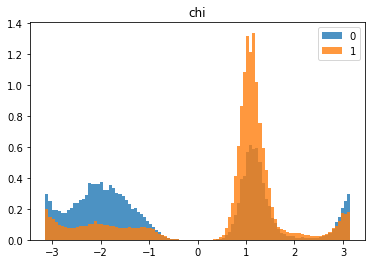

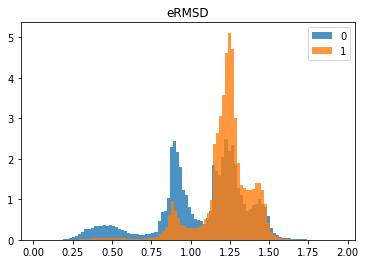

In [14]:
obs_names = ['chi', 'eRMSD']

for name in obs_names:
    plt.figure()
    plt.title(name)

    for i in range(2):
        plt.hist(my_df[name][my_df['n_prot'] == i], weights=my_df['weight'][my_df['n_prot'] == i],
                alpha=0.8, bins=100, label=i, density=True)

    plt.legend()

In [15]:
weights = {}

for n_prot in ns_prot:
    weights[n_prot] = np.array(my_df['weight'][my_df['n_prot'] == n_prot])
    weights[n_prot] /= np.sum(weights[n_prot])

weights

{0: array([4.42346099e-07, 1.18166257e-05, 1.02347386e-07, ...,
        4.79335366e-05, 2.67926326e-05, 1.36390210e-05]),
 1: array([7.85449964e-06, 1.57876092e-05, 2.12651042e-07, ...,
        6.97012053e-07, 5.35629209e-06, 2.53526442e-06])}

In [16]:
from pH_refine import ManageIndices

In [17]:
g_exp = ManageIndices.flatten(np.array(pandas.DataFrame(avs)))
sigma_exp = ManageIndices.flatten(np.array(pandas.DataFrame(errs)))

legend_matrix = ManageIndices.build_legend(np.array(pandas.DataFrame(avs)))[0]


In [18]:
data = PHData(g_exp, sigma_exp, legend_matrix, gs, weights, None, ref_pH, ref_pops, pops, log_fugacities, ns_prot, obs_names, pH_vals)

In [19]:
data.keys()

dict_keys(['g_exp', 'sigma_exp', 'legend_matrix', 'gs', 'p0s', 'legend_weights', 'ref_pH', 'ref_pops', 'pops', 'log_fugacities', 'ns_prot', 'obs_names', 'pH_vals'])

In [20]:
data.pops

{3.0: Array([0.09835848, 0.90164152], dtype=float64),
 3.5: Array([0.2564875, 0.7435125], dtype=float64),
 4.0: Array([0.52173302, 0.47826698], dtype=float64)}

### 2nd step: evaluate the loss function for the original `data`

In [ ]:
pi_vec = data.ref_pops
lambdas_vec = np.zeros(len(data.g_exp))

out = pH_loss(lambdas=lambdas_vec, pis=pi_vec, data=data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(179.22823975, dtype=float64)
        chi2: Array(358.45647951, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(179.22823975, dtype=float64)
    rel_diff: Array([[-1.72361435,  1.95070215, -5.17325455],
                     [12.53433018, 11.36239062,  6.22129231]], dtype=float64)

### 3rd step: minimize the loss function through `pH_tilde_loss`
(dimensionality reduction with `lambdas`)

In [61]:
log_pi_vec = np.log(pi_vec)


In [62]:
# is_fixed = False, so inner minimization of Gamma (required to compute the gradient)
lambdas = Lambdas(np.zeros(len(data.g_exp)), False)

pH_tilde_loss_and_grad(log_pi_vec, data, lambdas)


loss, grad:  8.12926883667112 [-10.44251122  10.44251122]
pi_vec:  [0.51023236 0.48976764]




(Array(8.12926884, dtype=float64),
 Array([-10.44251122,  10.44251122], dtype=float64))

In [24]:
args = (data, lambdas)

mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)


loss, grad:  -1.1329434389867456e-16 [0. 0.]
pi_vec:  [0.51023236 0.48976764]




In [25]:
mini

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.1329434389867456e-16
        x: [-6.729e-01 -7.138e-01]
      nit: 0
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[1 0]
            [0 1]]
     nfev: 1
     njev: 1

In [26]:
x = mini.x

pi_new = np.exp(x)
pi_new /= np.sum(pi_new)

pi_new

array([0.51023236, 0.48976764])

In [27]:
vars(lambdas)

{'value': array([0., 0., 0., 0., 0., 0.]), 'is_fixed': False}

### 4. evaluate `pH_loss` on the optimal solution
- do the values of the loss function agree?
- is this value lower than the starting one?

In [28]:
out = pH_loss(lambdas.value, pi_new, data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

In [29]:
print(mini.fun, out.loss)

-1.1329434389867456e-16 7.693513204315125e-24


yes, they agree!

In [30]:
out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

### 5. modify synthetic "experimental" data
such that they do not match the original average values

In [31]:
print(g_exp)
print(data.sigma_exp*10)

[ 0.44512738  0.27747556 -0.00374353  1.20755134  1.18320177  1.14235782]
[0.15257762 0.14023983 0.13469085 0.01853883 0.01832573 0.01902298]


In [32]:
rescaling = 10
random_fact = np.random.normal(size=len(data.g_exp))
print(random_fact)

data.g_exp = g_exp + random_fact*data.sigma_exp*rescaling

data.g_exp

[ 0.17236143 -0.19507021  0.51732546 -1.25343302 -1.13623906 -0.62212923]


Array([0.47142588, 0.25011894, 0.06593548, 1.18431416, 1.16237936,
       1.13052306], dtype=float64)

In [33]:
lambdas = np.zeros(len(data.g_exp))
pH_loss(lambdas, pi_vec, data)

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(179.22823975, dtype=float64)
        chi2: Array(358.45647951, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(179.22823975, dtype=float64)
    rel_diff: Array([[-1.72361435,  1.95070215, -5.17325455],
                     [12.53433018, 11.36239062,  6.22129231]], dtype=float64)

In [34]:
log_pi_vec = np.log(pi_vec)
lambdas = Lambdas(np.zeros(len(data.g_exp)), False)

pH_tilde_loss_and_grad(log_pi_vec, data, lambdas)

loss, grad:  8.12926883667112 [-10.44251122  10.44251122]
pi_vec:  [0.51023236 0.48976764]




(Array(8.12926884, dtype=float64),
 Array([-10.44251122,  10.44251122], dtype=float64))

In [35]:
args = (data, lambdas)

mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)

loss, grad:  8.12926883667112 [-10.44251122  10.44251122]
pi_vec:  [0.51023236 0.48976764]


loss, grad:  5.666938999220562 [ 10.01957139 -10.01957139]
pi_vec:  [0.81294958 0.18705042]


loss, grad:  2.9096390928288582 [-2.3352844  2.3352844]
pi_vec:  [0.68349378 0.31650622]


loss, grad:  2.8062110577851858 [ 1.403897 -1.403897]
pi_vec:  [0.72707756 0.27292244]


loss, grad:  2.7524918120459545 [-0.03613076  0.03613076]
pi_vec:  [0.71115717 0.28884283]


loss, grad:  2.752438056138789 [-0.01814635  0.01814635]
pi_vec:  [0.7115633 0.2884367]


loss, grad:  2.752490877307145 [ 0.03597338 -0.03597338]
pi_vec:  [0.71197275 0.28802725]


loss, grad:  2.7524420132710725 [ 0.01988887 -0.01988887]
pi_vec:  [0.71161408 0.28838592]


loss, grad:  2.7524378874932163 [ 0.01969812 -0.01969812]
pi_vec:  [0.71157136 0.28842864]


loss, grad:  2.7524389464771 [ 0.01456605 -0.01456605]
pi_vec:  [0.71156717 0.28843283]


loss, grad:  2.7524404111784277 [ 0.01874448 -0.01874448]
pi_vec:  [0.71157115 0.2

In [36]:
mini

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 2.752438056138789
        x: [-2.419e-01 -1.145e+00]
      nit: 4
      jac: [-1.815e-02  1.815e-02]
 hess_inv: [[ 5.275e-01  4.725e-01]
            [ 4.725e-01  5.275e-01]]
     nfev: 26
     njev: 14

In [37]:
x = mini.x

pi_new = np.exp(x)
pi_new /= np.sum(pi_new)

pi_new

array([0.7115633, 0.2884367])

In [38]:
pKa = data.ref_pH - np.log10(pi_new[0]/pi_new[1])

print('optimal pKa: ', pKa)

optimal pKa:  3.5878369698256396


In [39]:
logf = -(pKa - ref_pH)*np.log(10)
compute_pH_weights(np.log(pi_new), logf, np.array([0, 1]))


Array([0.5, 0.5], dtype=float64)

In [40]:
out = pH_loss(lambdas.value, pi_new, data)

out

         avs: Array([[-0.15995156,  1.10255525],
                     [ 0.61962243,  1.20702275]], dtype=float64)
      avs_ph: Array([[0.45958254, 0.26911923, 0.05761026],
                     [1.18557646, 1.16005326, 1.13170981]], dtype=float64)
 check_gamma: Array(1.46792714e-05, dtype=float64)
        chi2: Array(5.2841135, dtype=float64)
       dkl_p: Array([0.01763269, 0.00881977], dtype=float64)
      dkl_pi: Array(0.08395026, dtype=float64)
       gamma: Array(-2.66849453, dtype=float64)
      log_ps: [Array([-14.57585892, -11.21406504, -16.060505  , ..., -10.02713069,
                     -10.58517068, -11.22549676], dtype=float64), Array([-11.74803012, -11.14564902, -15.34000092, ..., -14.21011653,
                     -12.24795469, -12.95664177], dtype=float64)]
        loss: Array(2.75245947, dtype=float64)
    rel_diff: Array([[-0.77621757,  1.35484247, -0.61809815],
                     [ 0.68089691, -1.26930915,  0.62385095]], dtype=float64)

In [41]:
print(out.loss, mini.fun)

if np.abs(out.loss - mini.fun) < 1e-3: print('yes, they agree!')
else: print('significant mismatch, possible errors!')

2.7524594686439485 2.752438056138789
yes, they agree!


### 6. define `pH_minimizer` function

so, let's define a function that minimizes the loss through `pH_tilde_loss` and returns results of `pH_loss`

In [87]:
def pH_minimizer(data, alpha_pi = 1., alphas = 1.):
    
    lambdas = Lambdas(np.zeros(len(data.g_exp)), False)
    args = (data, lambdas, alpha_pi, alphas)

    mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)

    pi_new = np.exp(mini.x)
    pi_new /= np.sum(pi_new)

    out = pH_loss(lambdas.value, pi_new, data, alphas, alpha_pi)
    
    out.lambdas = lambdas.value
    out.pi_new = pi_new
    out.mini = mini
    out.diff = np.abs(out.loss - mini.fun)

    if out.diff < 1e-3: print('yes, they agree!')
    else: print('significant mismatch, possible errors!')

    pKa = data.ref_pH - np.log10(pi_new[0]/pi_new[1])
    out.optimal_pKa = pKa

    return out

In [88]:
result = pH_minimizer(data, alpha_pi=10.)

loss, grad:  8.129268836671118 [-10.44251122  10.44251122]
pi_vec:  [0.51023236 0.48976764]


loss, grad:  7.454593817658532 [ 11.97436623 -11.97436623]
pi_vec:  [0.81294958 0.18705042]


loss, grad:  3.5592475553106606 [-2.06194107  2.06194107]
pi_vec:  [0.66958524 0.33041476]


loss, grad:  3.4659505187299686 [ 0.96004819 -0.96004819]
pi_vec:  [0.70474931 0.29525069]


loss, grad:  3.4416769046549276 [-0.02372872  0.02372872]
pi_vec:  [0.69381365 0.30618635]


loss, grad:  3.4416549840310964 [-0.01109859  0.01109859]
pi_vec:  [0.69408007 0.30591993]


loss, grad:  3.4416491051612925 [ 0.00041603 -0.00041603]
pi_vec:  [0.69431408 0.30568592]


loss, grad:  3.4416722268263262 [ 0.02171224 -0.02171224]
pi_vec:  [0.69430563 0.30569437]


loss, grad:  3.441673097980549 [ 0.0218658 -0.0218658]
pi_vec:  [0.69431408 0.30568592]


loss, grad:  3.4416730980832897 [ 0.02186472 -0.02186472]
pi_vec:  [0.69431408 0.30568592]


loss, grad:  3.4416730980832897 [ 0.02186472 -0.02186472]
pi_vec:  [0.6

In [89]:
result

         avs: Array([[-0.17526104,  1.10034199],
                     [ 0.60814028,  1.20562455]], dtype=float64)
      avs_ph: Array([[0.45761787, 0.27185812, 0.05662591],
                     [1.1853956 , 1.16043105, 1.13150565]], dtype=float64)
 check_gamma: Array(1.81133634e-05, dtype=float64)
        chi2: Array(5.4370503, dtype=float64)
        diff: 4.211251480734646e-05
       dkl_p: Array([0.01607649, 0.0091188 ], dtype=float64)
      dkl_pi: Array(0.06979708, dtype=float64)
       gamma: Array(-2.74370233, dtype=float64)
     lambdas: array([ -59.35360341,  110.49426869,  -51.30012591,  313.57001587,
                     -582.0172769 ,  269.20000237])
      log_ps: [Array([-14.57804631, -11.21643511, -16.05937322, ..., -10.0247887 ,
                     -10.58295795, -11.22572259], dtype=float64), Array([-11.73780355, -11.13890942, -15.33385461, ..., -14.20543222,
                     -12.24346849, -12.95205385], dtype=float64)]
        loss: Array(3.44169122, dtype=float64)


In [93]:
result.diff

4.211251480734646e-05